In [1]:
import pandas as pd

dev_data = pd.read_csv('development.csv')
eval_data = pd.read_csv('evaluation.csv')

print("Development Data:")
print(dev_data.head())
print("\nEvaluation Data:")
print(eval_data.head())

Development Data:
   Id  sampling_rate   age  gender   ethnicity  mean_pitch  max_pitch  \
0   0          22050  24.0  female      arabic   1821.6906  3999.7170   
1   1          22050  22.5  female   hungarian   1297.8187  3998.8590   
2   2          22050  22.0  female  portuguese   1332.8524  3998.8025   
3   3          22050  22.0  female     english   1430.3499  3998.4510   
4   4          22050  22.0    male       dutch   1688.7234  3998.6113   

   min_pitch    jitter   shimmer    energy  zcr_mean  spectral_centroid_mean  \
0  145.43066  0.013795  0.082725  0.002254  0.210093             3112.257251   
1  145.37268  0.025349  0.096242  0.007819  0.078849             1688.016389   
2  145.42395  0.019067  0.119456  0.002974  0.105365             2576.901706   
3  147.98083  0.017004  0.102389  0.022371  0.173701             3269.751413   
4  145.44772  0.028027  0.124831  0.005369  0.107279             1930.897375   

            tempo         hnr  num_words  num_characters  num_

In [2]:
print("Missing val in Development Data:")
print(dev_data.isnull().sum())
print("\nMissing val in Evaluation Data:")
print(eval_data.isnull().sum())

Missing val in Development Data:
Id                        0
sampling_rate             0
age                       0
gender                    0
ethnicity                 0
mean_pitch                0
max_pitch                 0
min_pitch                 0
jitter                    0
shimmer                   0
energy                    0
zcr_mean                  0
spectral_centroid_mean    0
tempo                     0
hnr                       0
num_words                 0
num_characters            0
num_pauses                0
silence_duration          0
path                      0
dtype: int64

Missing val in Evaluation Data:
Id                        0
sampling_rate             0
gender                    0
ethnicity                 0
mean_pitch                0
max_pitch                 0
min_pitch                 0
jitter                    0
shimmer                   0
energy                    0
zcr_mean                  0
spectral_centroid_mean    0
tempo                    

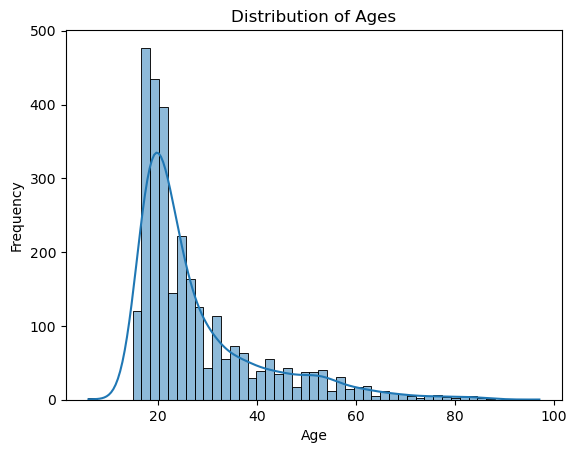

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

#distribution of ages
sns.histplot(dev_data['age'], kde=True)
plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [4]:
print(dev_data.describe())

                Id  sampling_rate          age   mean_pitch    max_pitch  \
count  2933.000000         2933.0  2933.000000  2933.000000  2933.000000   
mean   1466.000000        22050.0    27.897886  1189.536569  3779.570485   
std     846.828495            0.0    13.093316   414.193673   532.847869   
min       0.000000        22050.0     6.000000   346.974330   935.515560   
25%     733.000000        22050.0    19.000000   818.922360  3948.234400   
50%    1466.000000        22050.0    23.000000  1208.998300  3998.397200   
75%    2199.000000        22050.0    32.000000  1523.777700  3999.485400   
max    2932.000000        22050.0    97.000000  2724.892800  3999.792500   

         min_pitch       jitter      shimmer       energy     zcr_mean  \
count  2933.000000  2933.000000  2933.000000  2933.000000  2933.000000   
mean    146.934930     0.021190     0.107741     0.005208     0.104774   
std       3.757917     0.006626     0.029005     0.006074     0.051646   
min     145.349140 

In [5]:
#one-hot 'gender'&'ethnicity'
dev_data = pd.get_dummies(dev_data, columns=['gender', 'ethnicity'], drop_first=True)
eval_data = pd.get_dummies(eval_data, columns=['gender', 'ethnicity'], drop_first=True)
print(dev_data.head())

   Id  sampling_rate   age  mean_pitch  max_pitch  min_pitch    jitter  \
0   0          22050  24.0   1821.6906  3999.7170  145.43066  0.013795   
1   1          22050  22.5   1297.8187  3998.8590  145.37268  0.025349   
2   2          22050  22.0   1332.8524  3998.8025  145.42395  0.019067   
3   3          22050  22.0   1430.3499  3998.4510  147.98083  0.017004   
4   4          22050  22.0   1688.7234  3998.6113  145.44772  0.028027   

    shimmer    energy  zcr_mean  ...  ethnicity_russian ethnicity_rwanda  \
0  0.082725  0.002254  0.210093  ...              False            False   
1  0.096242  0.007819  0.078849  ...              False            False   
2  0.119456  0.002974  0.105365  ...              False            False   
3  0.102389  0.022371  0.173701  ...              False            False   
4  0.124831  0.005369  0.107279  ...              False            False   

   ethnicity_sa'a  ethnicity_sardinian  ethnicity_sarua  ethnicity_satawalese  \
0           False

In [6]:
eval_data = eval_data.reindex(columns=dev_data.columns, fill_value=0)

In [7]:
#remove [] -> float
dev_data['tempo'] = dev_data['tempo'].str.strip('[]').astype(float)
eval_data['tempo'] = eval_data['tempo'].str.strip('[]').astype(float)
print(dev_data['tempo'].head())

0    151.999081
1    129.199219
2    117.453835
3    117.453835
4    112.347147
Name: tempo, dtype: float64


In [8]:
from sklearn.preprocessing import StandardScaler
numerical_features = [
        'mean_pitch',
        'max_pitch',
        'min_pitch',
        'jitter',
        'shimmer',
        'energy',
        'zcr_mean',
        'spectral_centroid_mean',
        'tempo',
        'hnr',
        'num_words',
        'num_characters',
        'num_pauses',
        'silence_duration'
]

scale = StandardScaler()

dev_data[numerical_features] = scale.fit_transform(dev_data[numerical_features])
eval_data[numerical_features] = scale.transform(eval_data[numerical_features])
print(dev_data[numerical_features].head())

   mean_pitch  max_pitch  min_pitch    jitter   shimmer    energy  zcr_mean  \
0    1.526488   0.413221  -0.400362 -1.116336 -0.862609 -0.486481  2.039603   
1    0.261473   0.411611  -0.415793  0.627830 -0.396497  0.429809 -0.502063   
2    0.346071   0.411505  -0.402148 -0.320350  0.403982 -0.367850  0.011442   
3    0.581502   0.410845   0.278367 -0.631887 -0.184536  2.825886  1.334833   
4    1.205407   0.411146  -0.395821  1.032230  0.589336  0.026396  0.048513   

   spectral_centroid_mean     tempo       hnr  num_words  num_characters  \
0                1.616870  0.796088 -1.287020   0.844879        0.845057   
1               -0.843696  0.121675 -0.322635   0.844879        0.845057   
2                0.691972 -0.225751 -0.622378   0.844879        0.845057   
3                1.888962 -0.225751  0.469989   0.844879        0.845057   
4               -0.424086 -0.376805 -0.151479   0.844879        0.845057   

   num_pauses  silence_duration  
0    1.862330          0.954642  


In [9]:
print(dev_data[numerical_features].mean())
print(dev_data[numerical_features].std())

mean_pitch                4.094160e-16
max_pitch                -1.080471e-15
min_pitch                -1.090161e-15
jitter                   -2.252999e-16
shimmer                  -1.532282e-16
energy                    5.208547e-17
zcr_mean                  6.662095e-17
spectral_centroid_mean   -9.932578e-17
tempo                    -8.721288e-17
hnr                      -1.247629e-16
num_words                -6.056450e-17
num_characters           -5.390241e-17
num_pauses                4.966289e-17
silence_duration         -2.785967e-17
dtype: float64
mean_pitch                1.000171
max_pitch                 1.000171
min_pitch                 1.000171
jitter                    1.000171
shimmer                   1.000171
energy                    1.000171
zcr_mean                  1.000171
spectral_centroid_mean    1.000171
tempo                     1.000171
hnr                       1.000171
num_words                 1.000171
num_characters            1.000171
num_pauses         

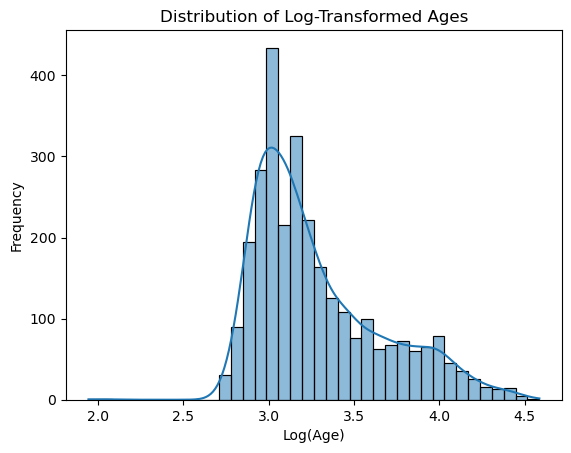

In [10]:
import numpy as np

dev_data['age'] = np.log1p(dev_data['age'])
sns.histplot(dev_data['age'], kde=True)
plt.title('Distribution of Log-Transformed Ages')
plt.xlabel('Log(Age)')
plt.ylabel('Frequency')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

#features(X) $ target(y)
X = dev_data.drop(columns=['age', 'path', 'Id'])  #drop non-feature
y = dev_data['age']

#split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#shape
print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)

Train shape: (2346, 180) (2346,)
Val shape: (587, 180) (587,)


In [12]:
import librosa
import librosa.display

#load wav
audio_path = 'audios_development/2.wav'
y, smr = librosa.load(audio_path, sr=None)
print(f"Sampling rate: {smr}")
print(f"Audio length: {len(y) / smr}")

Sampling rate: 44100
Audio length: 23.33126984126984


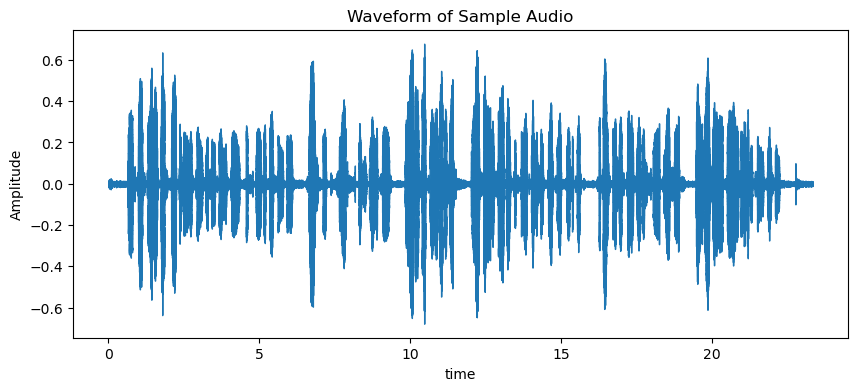

In [13]:
#waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=smr)
plt.title('Waveform of Sample Audio')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.show()

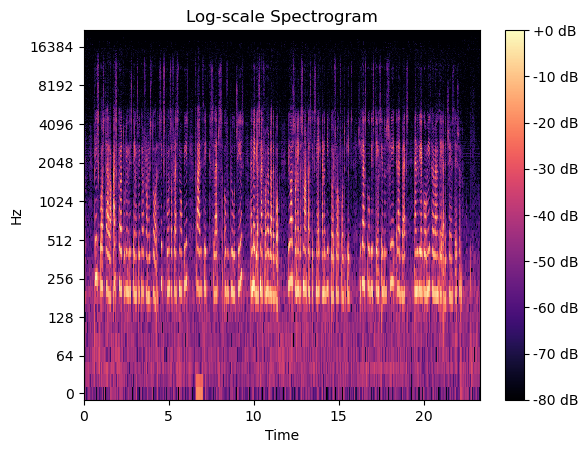

In [14]:
spec = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(spec, sr=smr, x_axis='time', y_axis='log')
plt.title('Log-scale Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()

In [15]:
intervals = librosa.effects.split(y, top_db=20)
print(f"Detected speech intervals: {intervals}")

Detected speech intervals: [[ 27648  36864]
 [ 42496  51200]
 [ 56832  72192]
 [ 75776  83456]
 [ 91136  99840]
 [102912 122880]
 [128512 138240]
 [141312 146432]
 [149504 156672]
 [160768 173056]
 [179200 192512]
 [200192 204800]
 [215040 223744]
 [225792 230912]
 [234496 241664]
 [246784 256000]
 [259584 269312]
 [291840 306688]
 [312320 318976]
 [335872 347648]
 [364544 377344]
 [380928 393728]
 [399360 411136]
 [432640 454656]
 [456192 464384]
 [468992 505344]
 [528896 542720]
 [546816 564224]
 [567808 578560]
 [580608 587776]
 [592384 595968]
 [601600 612352]
 [616960 635904]
 [641536 649728]
 [654336 662016]
 [668160 675840]
 [676352 679424]
 [683520 689664]
 [715264 718848]
 [721408 730624]
 [735744 751104]
 [757248 767488]
 [770560 786944]
 [794112 805888]
 [810496 834560]
 [857088 898048]
 [902656 921088]
 [922624 941056]
 [946688 957440]
 [962048 968704]
 [972800 980480]]


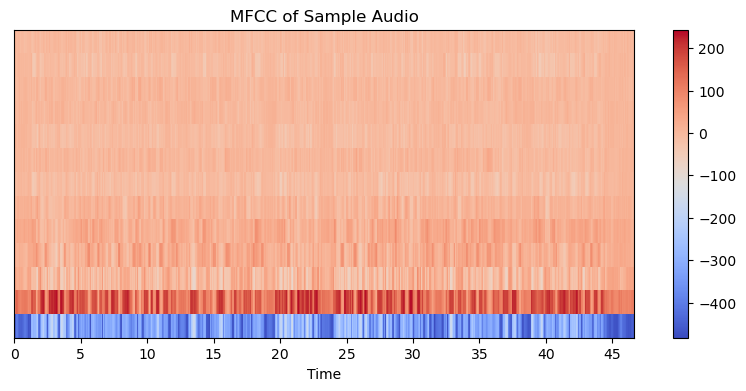

In [16]:
#extract mfcc(Mel-frequency cepstral coefficients)
mfccs = librosa.feature.mfcc(y=y, sr=smr, n_mfcc=13)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title('MFCC of Sample Audio')
plt.show()

In [17]:
#func to get audio features
def get_audio_features(audio_file):
    audio, smr = librosa.load(audio_file, sr=None)
    
    #get mfcc
    mfccs = librosa.feature.mfcc(y=audio, sr=smr, n_mfcc=13)
    mfccs_avg = np.mean(mfccs, axis=1)
    
    #get chroma
    chroma = librosa.feature.chroma_stft(y=audio, sr=smr)
    chroma_avg = np.mean(chroma, axis=1)
    
    #get Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=audio, sr=smr)
    contrast_avg = np.mean(contrast, axis=1)
    
    #combine them
    all_features = np.hstack([mfccs_avg, chroma_avg, contrast_avg])
    return all_features

#test?!
file_path = 'audios_development/1.wav'
features = get_audio_features(file_path)
print("Num of features extracted:", features.shape)

Num of features extracted: (32,)


In [18]:
#apply feature extraction to all audio files
dev_audio_features = []
for path in dev_data['path']:
    features = get_audio_features(path)
    dev_audio_features.append(features)

#convert to dataframe
dev_audio_features = pd.DataFrame(dev_audio_features)
dev_audio_features.columns = [f'mfcc_{i}' for i in range(13)] + [f'chroma_{i}' for i in range(12)] + [f'spectral_contrast_{i}' for i in range(7)]

#merge the features with dev dataset
dev_data = pd.concat([dev_data, dev_audio_features], axis=1)

#repeat for eval
eval_audio_features = []
for path in eval_data['path']:
    features = get_audio_features(path)
    eval_audio_features.append(features)
#convert to dataframe
eval_audio_features = pd.DataFrame(eval_audio_features)
eval_audio_features.columns = [f'mfcc_{i}' for i in range(13)] + [f'chroma_{i}' for i in range(12)] + [f'spectral_contrast_{i}' for i in range(7)]

#merge
eval_data = pd.concat([eval_data, eval_audio_features], axis=1)

In [19]:
#list of new numerical features
new_numerical_features = [f'mfcc_{i}' for i in range(13)] + [f'chroma_{i}' for i in range(12)] + [f'spectral_contrast_{i}' for i in range(7)]

scale = StandardScaler()

#fit and transform dev
dev_data[new_numerical_features] = scale.fit_transform(dev_data[new_numerical_features])

#sane for eval
eval_data[new_numerical_features] = scale.transform(eval_data[new_numerical_features])

#split the data again
X = dev_data.drop(columns=['age', 'path', 'Id'])
y = dev_data['age']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#check
print("new-training set shape:", X_train.shape, y_train.shape)
print("new-validation set shape:", X_val.shape, y_val.shape)

new-training set shape: (2346, 212) (2346,)
new-validation set shape: (587, 212) (587,)


In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

#train dt
dt_model.fit(X_train, y_train)
y_predict_dt = dt_model.predict(X_val)
rmse_dt = np.sqrt(mean_squared_error(y_val, y_predict_dt))
print(f"Decision Tree RMSE: {rmse_dt}")

# train rt
rf_model.fit(X_train, y_train)
y_predict_rf = rf_model.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_predict_rf))
print(f"Random Forest RMSE: {rmse_rf}")

Decision Tree RMSE: 0.3814424452377615
Random Forest RMSE: 0.2710229105965669


In [22]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_predict_ridge = ridge_model.predict(X_val)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_predict_ridge))
print("Ridge Regression RMSE:", rmse_ridge)

Ridge Regression RMSE: 0.27145642676517745


In [23]:
eval_features = eval_data.drop(columns=['path', 'Id', 'age'])
eval_features = eval_features.reindex(columns=X_train.columns, fill_value=0)

eval_predictions = rf_model.predict(eval_features)

#convert to org scale
eval_predictions_original = np.expm1(eval_predictions)
print("Predictions on evaluation data (first 10):", eval_predictions_original[:10])

Predictions on evaluation data (first 10): [29.55455442 28.67244845 23.93915178 28.01424764 31.26306837 22.3166489
 24.86770562 19.35834413 38.36611627 22.69595203]


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict on validation set
y_pred_val = ridge_model.predict(X_val)

# Compute RMSE
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"Validation RMSE: {rmse_val}")

Validation RMSE: 0.27145642676517745


In [25]:
# Extract features for the evaluation set
X_eval = eval_data.drop(columns=['path', 'Id'])

In [26]:
# Align evaluation dataset features with training features
X_eval = X_eval.reindex(columns=X_train.columns, fill_value=0)

In [27]:
# Predict on the aligned evaluation dataset
eval_predictions = ridge_model.predict(X_eval)

In [28]:
# Reverse log transformation (if applicable)
eval_predictions_original = np.expm1(eval_predictions)

In [29]:
print(eval_predictions_original[:10])

[34.25296379 33.26029584 21.22065192 33.52501046 33.76058148 18.6417651
 29.01434244 20.62094505 35.29914347 20.79164234]


In [30]:
print("First few values of y_train:")
print(y_train.head())

# If the values are small and consistent with a logarithmic scale, the target was transformed.

First few values of y_train:
834     2.833213
1898    2.995732
678     3.258097
700     2.890372
2073    3.332205
Name: age, dtype: float64


In [31]:
# Reverse log transformation for predictions and actual values
y_pred_original = np.expm1(y_pred_val)
y_val_original = np.expm1(y_val)

In [32]:
from sklearn.metrics import mean_squared_error

rmse_original_scale = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
print(f"Validation RMSE (Original Scale): {rmse_original_scale}")

Validation RMSE (Original Scale): 9.737081696847126


Top 10 Features:
silence_duration       0.331041
mfcc_5                 0.042403
mfcc_7                 0.028730
jitter                 0.020917
spectral_contrast_0    0.020510
mfcc_8                 0.018989
chroma_5               0.018657
hnr                    0.017933
mfcc_10                0.017775
ethnicity_english      0.017355
dtype: float64


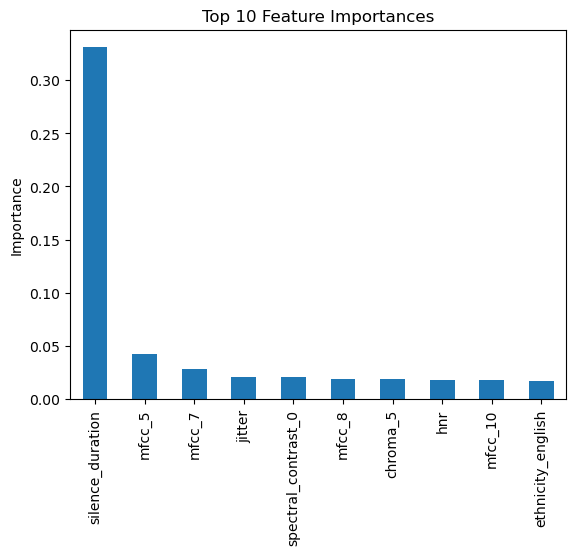

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

# Extract and display feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print("Top 10 Features:")
print(feature_importances.sort_values(ascending=False).head(10))

# Optionally, plot feature importance
import matplotlib.pyplot as plt
top_features = feature_importances.sort_values(ascending=False).head(10)
top_features.plot(kind='bar', title='Top 10 Feature Importances')
plt.ylabel('Importance')
plt.show()

In [38]:
important_features = feature_importances[feature_importances > 0.01].index
X_train_important = X_train[important_features]
X_val_important = X_val[important_features]

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gbr = GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.1)
gbr.fit(X_train_important, y_train)

# Predict and evaluate on validation set
y_pred_gbr = gbr.predict(X_val_important)
rmse_gbr = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred_gbr)))
print(f"Gradient Boosting RMSE (Original Scale): {rmse_gbr}")

Gradient Boosting RMSE (Original Scale): 9.417226551986712


In [41]:
# Align evaluation data to have the same columns as the training data
X_eval_important = eval_data.reindex(columns=X_train_important.columns, fill_value=0)

In [45]:
# Predict on the aligned evaluation set
eval_predictions = gbr.predict(X_eval_important)

# Reverse log transformation (if applicable)
eval_predictions_original = np.expm1(eval_predictions)

# Save predictions
submission = pd.DataFrame({'Id': eval_data['Id'], 'Predicted': eval_predictions_original})
submission.to_csv('final_gradient_boosting_submission.csv', index=False)
print("Submission file saved as 'final_gradient_boosting_submission.csv'")

Submission file saved as 'final_gradient_boosting_submission.csv'


In [48]:
# Reverse log transformation (if log1p was applied)
y_val_original = np.expm1(y_val)
y_pred_original = np.expm1(y_pred_gbr)

# Calculate RMSE in the original scale
rmse_original = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
print(f"Gradient Boosting RMSE (Original Scale): {rmse_original}")

Gradient Boosting RMSE (Original Scale): 9.417226551986712


In [49]:
from sklearn.model_selection import KFold, GridSearchCV

# Define k-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.8, 1.0]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=gbr_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=kfold,
    verbose=1,
    n_jobs=-1
)

# Train with GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and RMSE
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)
print("Best Parameters:", best_params)
print("Best RMSE (Log Scale):", best_rmse)

# Final model training on full training data
final_gbr = GradientBoostingRegressor(**best_params, random_state=42)
final_gbr.fit(X_train, y_train)

# Predict on validation set
y_pred_gbr = final_gbr.predict(X_val)

# Reverse log transformation (if applicable)
y_pred_gbr_original = np.expm1(y_pred_gbr)
y_val_original = np.expm1(y_val)

# Calculate RMSE on original scale
rmse_gbr_original = np.sqrt(mean_squared_error(y_val_original, y_pred_gbr_original))
print(f"Validation RMSE (Original Scale): {rmse_gbr_original}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best RMSE (Log Scale): 0.2795838120731011
Validation RMSE (Original Scale): 9.129506716650477


In [50]:
# Ensure the evaluation dataset has the same features
X_eval_important = eval_data.reindex(columns=X_train.columns, fill_value=0)

# Predict on the evaluation set using the final Gradient Boosting model
eval_predictions = final_gbr.predict(X_eval_important)

# Reverse the log transformation (if applicable)
eval_predictions_original = np.expm1(eval_predictions)  # Use np.expm1 if log1p was applied to `age`

# Save predictions to a submission file
submission = pd.DataFrame({'Id': eval_data['Id'], 'Predicted': eval_predictions_original})
submission.to_csv('gradient_boosting_submission.csv', index=False)

print("Submission file saved as 'gradient_boosting_submission.csv'")

Submission file saved as 'gradient_boosting_submission.csv'


In [55]:
final_gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_split=5,  # Regularization
    min_samples_leaf=2,   # Regularization
    random_state=42
)
final_gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=2,
                          min_samples_split=5, n_estimators=300,
                          random_state=42, subsample=0.8)

In [56]:
# Predict on the validation set
y_pred_gbr = final_gbr.predict(X_val)

# Reverse log transformation
y_pred_gbr_original = np.expm1(y_pred_gbr)
y_val_original = np.expm1(y_val)

# Calculate RMSE
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_gbr))
rmse_original = np.sqrt(mean_squared_error(y_val_original, y_pred_gbr_original))

print(f"Validation RMSE (Log Scale): {rmse_log}")
print(f"Validation RMSE (Original Scale): {rmse_original}")

Validation RMSE (Log Scale): 0.2561290771889962
Validation RMSE (Original Scale): 9.074924233706462


In [57]:
# Align evaluation dataset with training features
X_eval_important = eval_data.reindex(columns=X_train.columns, fill_value=0)

# Predict on evaluation dataset
eval_predictions = final_gbr.predict(X_eval_important)
eval_predictions_original = np.expm1(eval_predictions)

# Save predictions
submission = pd.DataFrame({'Id': eval_data['Id'], 'Predicted': eval_predictions_original})
submission.to_csv('gradient_boosting_submission.csv', index=False)
print("Submission file saved as 'gradient_boosting_submission.csv'")

Submission file saved as 'gradient_boosting_submission.csv'
